In [3]:
import torch
import math
max_timescale=1e6
d_model=128
half = d_model // 2
freqs = torch.exp(
            -torch.arange(half, dtype=torch.float32) * (math.log(max_timescale) / half)
        )

In [5]:
pi_greco = 3.14

In [7]:
sec_to_hour = 1 / (3600)
sec_to_days = sec_to_hour / 24

In [8]:
2*pi_greco / freqs * sec_to_days

tensor([7.2685e-05, 9.0198e-05, 1.1193e-04, 1.3890e-04, 1.7236e-04, 2.1389e-04,
        2.6543e-04, 3.2938e-04, 4.0874e-04, 5.0722e-04, 6.2943e-04, 7.8108e-04,
        9.6927e-04, 1.2028e-03, 1.4926e-03, 1.8522e-03, 2.2985e-03, 2.8523e-03,
        3.5395e-03, 4.3923e-03, 5.4506e-03, 6.7639e-03, 8.3936e-03, 1.0416e-02,
        1.2925e-02, 1.6040e-02, 1.9904e-02, 2.4700e-02, 3.0651e-02, 3.8036e-02,
        4.7200e-02, 5.8573e-02, 7.2685e-02, 9.0198e-02, 1.1193e-01, 1.3890e-01,
        1.7236e-01, 2.1389e-01, 2.6543e-01, 3.2938e-01, 4.0874e-01, 5.0722e-01,
        6.2943e-01, 7.8108e-01, 9.6927e-01, 1.2028e+00, 1.4926e+00, 1.8522e+00,
        2.2985e+00, 2.8523e+00, 3.5395e+00, 4.3923e+00, 5.4506e+00, 6.7639e+00,
        8.3936e+00, 1.0416e+01, 1.2925e+01, 1.6040e+01, 1.9904e+01, 2.4700e+01,
        3.0651e+01, 3.8036e+01, 4.7200e+01, 5.8573e+01])

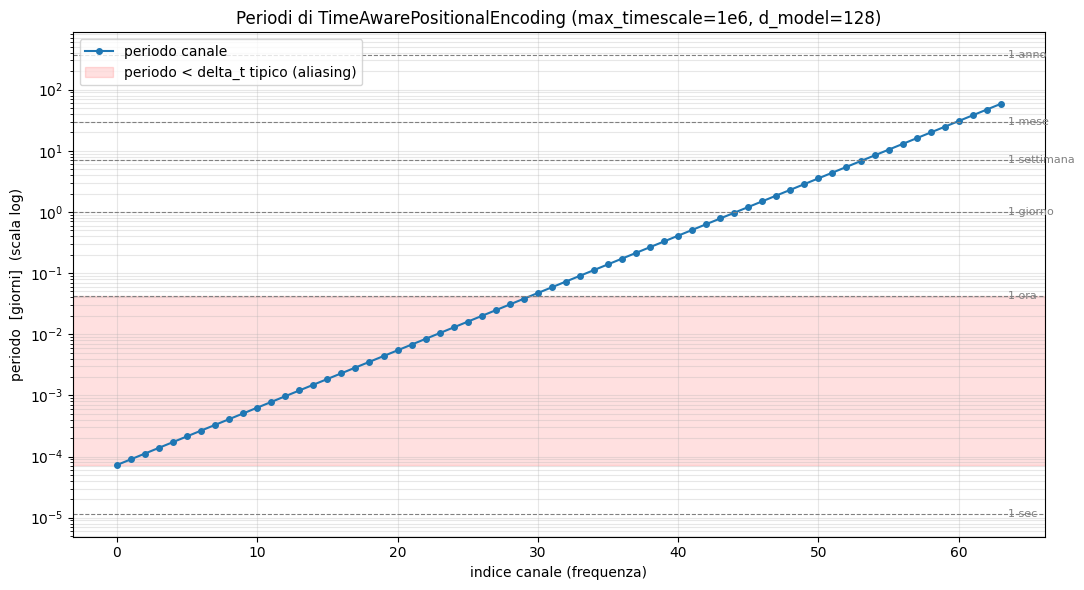

periodo min: 6.28 s
periodo max: 58.6 giorni
canali con periodo < 1 ora: 30 / 64


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Periodo di ogni canale del PE, in giorni:  T = 2*pi / omega
periods_days = (2 * np.pi / freqs * sec_to_days).numpy()
channels = np.arange(len(periods_days))

# Riferimenti temporali (in giorni)
refs = {"1 sec": 1 / 86400, "1 ora": 1 / 24, "1 giorno": 1.0,
        "1 settimana": 7.0, "1 mese": 30.0, "1 anno": 365.0}

# delta_t reali: da ore a giorni (10^5–10^6 s ≈ 1–12 giorni)
dt_min, dt_max = 1 / 24, 12.0  # giorni

fig, ax = plt.subplots(figsize=(11, 6))
ax.semilogy(channels, periods_days, "o-", ms=4, color="tab:blue", label="periodo canale")

# zona aliasata: periodo molto più corto del minimo delta_t risolvibile
ax.axhspan(periods_days.min(), dt_min, color="red", alpha=0.12,
           label="periodo < delta_t tipico (aliasing)")

for name, d in refs.items():
    ax.axhline(d, color="gray", ls="--", lw=0.8)
    ax.text(len(channels) - 1, d, f"  {name}", va="center", fontsize=8, color="gray")

ax.set_xlabel("indice canale (frequenza)")
ax.set_ylabel("periodo  [giorni]  (scala log)")
ax.set_title("Periodi di TimeAwarePositionalEncoding (max_timescale=1e6, d_model=128)")
ax.legend(loc="upper left")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"periodo min: {periods_days.min()*86400:.2f} s")
print(f"periodo max: {periods_days.max():.1f} giorni")
print(f"canali con periodo < 1 ora: {(periods_days < 1/24).sum()} / {len(periods_days)}")


In [4]:
freqs

tensor([1.0000e+00, 8.0584e-01, 6.4938e-01, 5.2330e-01, 4.2170e-01, 3.3982e-01,
        2.7384e-01, 2.2067e-01, 1.7783e-01, 1.4330e-01, 1.1548e-01, 9.3057e-02,
        7.4989e-02, 6.0430e-02, 4.8697e-02, 3.9242e-02, 3.1623e-02, 2.5483e-02,
        2.0535e-02, 1.6548e-02, 1.3335e-02, 1.0746e-02, 8.6596e-03, 6.9783e-03,
        5.6234e-03, 4.5316e-03, 3.6517e-03, 2.9427e-03, 2.3714e-03, 1.9110e-03,
        1.5399e-03, 1.2409e-03, 1.0000e-03, 8.0584e-04, 6.4938e-04, 5.2330e-04,
        4.2170e-04, 3.3982e-04, 2.7384e-04, 2.2067e-04, 1.7783e-04, 1.4330e-04,
        1.1548e-04, 9.3057e-05, 7.4989e-05, 6.0430e-05, 4.8697e-05, 3.9242e-05,
        3.1623e-05, 2.5483e-05, 2.0535e-05, 1.6548e-05, 1.3335e-05, 1.0746e-05,
        8.6596e-06, 6.9783e-06, 5.6234e-06, 4.5316e-06, 3.6517e-06, 2.9427e-06,
        2.3714e-06, 1.9110e-06, 1.5399e-06, 1.2409e-06])

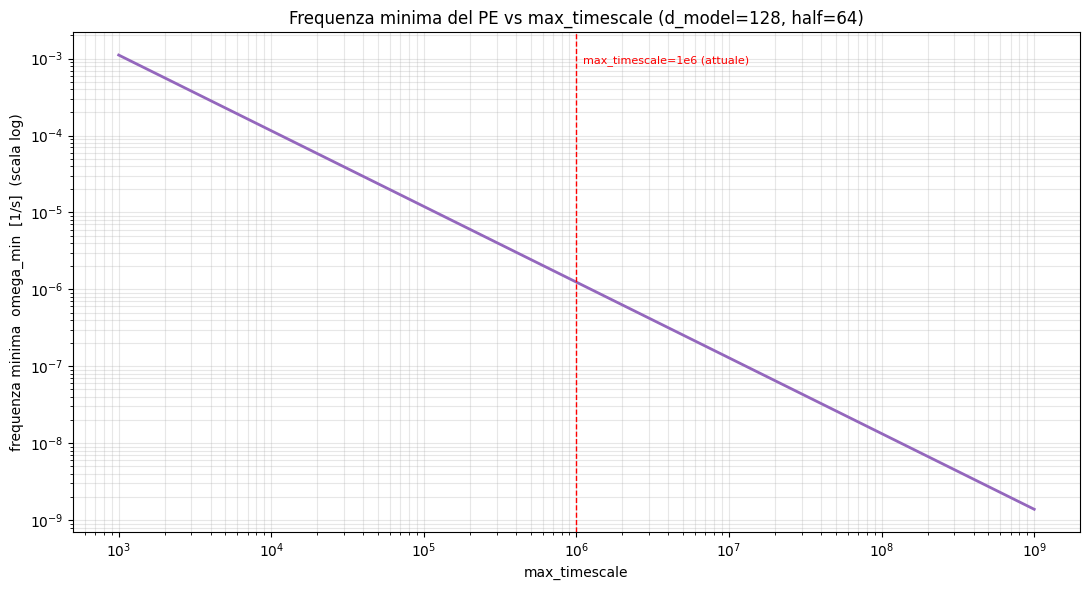

max_timescale=1e+03: omega_min=1.11e-03 1/s, periodo max=0.1 giorni
max_timescale=1e+06: omega_min=1.24e-06 1/s, periodo max=58.6 giorni
max_timescale=1e+09: omega_min=1.38e-09 1/s, periodo max=52606.7 giorni


In [13]:
# Frequenza minima del PE al variare di max_timescale.
# freqs = exp(-arange(half) * log(max_timescale)/half)
# la minima e' all'ultimo canale (i = half-1):
#   freq_min = max_timescale^(-(half-1)/half)  ~= 1/max_timescale
half = d_model // 2  # = 64

max_ts = np.logspace(3, 9, 200)            # da 1e3 a 1e9
freq_min = max_ts ** (-(half - 1) / half)  # 1/s

fig, ax = plt.subplots(figsize=(11, 6))
ax.loglog(max_ts, freq_min, color="tab:purple", lw=2)
ax.set_xlabel("max_timescale")
ax.set_ylabel("frequenza minima  omega_min  [1/s]  (scala log)")
ax.set_title(f"Frequenza minima del PE vs max_timescale (d_model={d_model}, half={half})")
ax.grid(True, which="both", alpha=0.3)

# valore attualmente usato nel modello
ax.axvline(1e6, color="red", ls="--", lw=1)
ax.text(1e6, freq_min[0], "  max_timescale=1e6 (attuale)", color="red", fontsize=8, va="top")

fig.tight_layout()
plt.show()

for mt in [1e3, 1e6, 1e9]:
    fm = mt ** (-(half - 1) / half)
    print(f"max_timescale={mt:.0e}: omega_min={fm:.2e} 1/s, periodo max={(2*np.pi/fm)/86400:.1f} giorni")
